## 1. Setup and Data Generation

We will create a synthetic dataset representing Real Estate Prices ($y$) based on Square Footage ($X_1$) and Age of Property ($X_2$).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Generate 200 samples
n = 200
sq_ft = np.random.normal(2000, 500, n)     # Feature 1
age = np.random.randint(1, 50, n)          # Feature 2

# Target: Price = (sq_ft * 150) - (age * 1000) + noise
noise = np.random.normal(0, 15000, n)
price = (sq_ft * 150) - (age * 1000) + 50000 + noise

# Add a few manual outliers for the Data Analysis section
price[0] = 850000
price[1] = 50000

# Create DataFrame
df = pd.DataFrame({'Sq_Ft': sq_ft, 'Age': age, 'Price': price})

df

,Sq_Ft,Age,Price
0,2248.357077,2,850000.000000
1,1930.867849,26,50000.000000
2,2323.844269,17,373728.818954
3,2761.514928,40,438464.384047
4,1882.923313,33,295850.124928
...,...,...,...
195,2192.658690,23,346508.909526
196,1558.071282,25,252982.038949
197,2076.862553,35,320327.614364
198,2029.104359,41,300936.897318


## 3d Visualisation

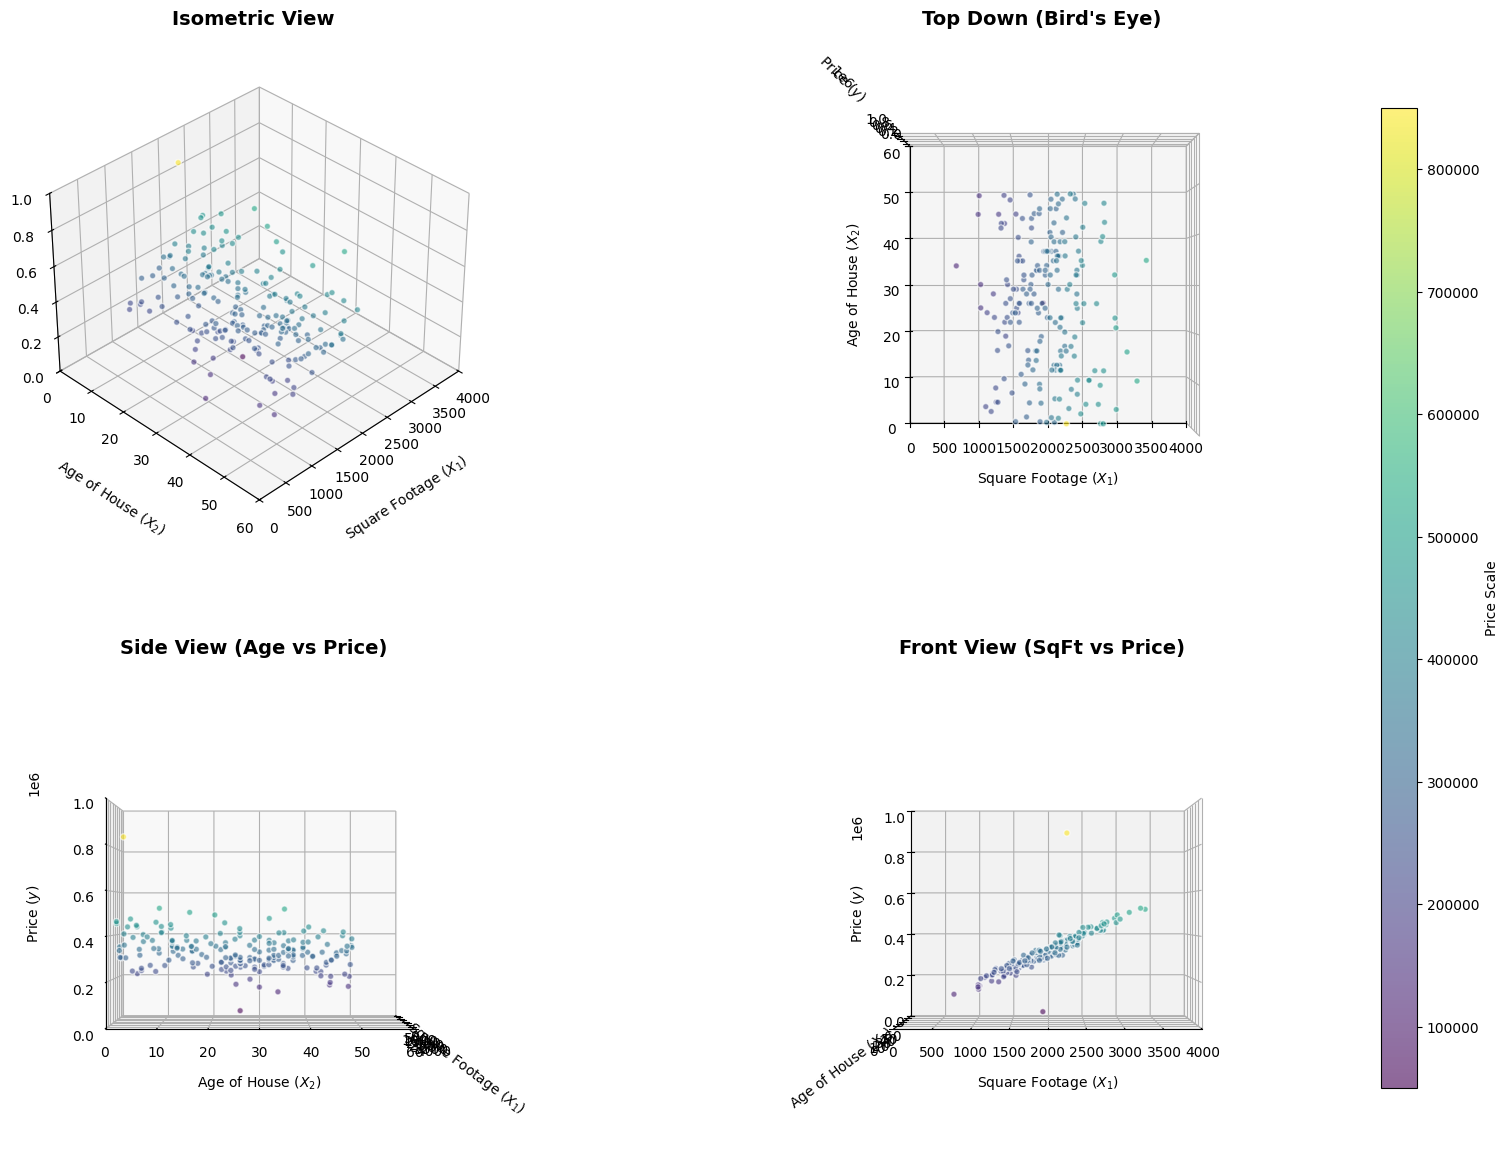

In [2]:
import matplotlib.pyplot as plt

views = [
    {'title': 'Isometric View', 'elev': 35, 'azim': 45},
    {'title': 'Top Down (Bird\'s Eye)', 'elev': 90, 'azim': -90},
    {'title': 'Side View (Age vs Price)', 'elev': 0, 'azim': 0},
    {'title': 'Front View (SqFt vs Price)', 'elev': 0, 'azim': -90}
]

fig = plt.figure(figsize=(18, 14))

for i, v in enumerate(views, 1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    
    # Plotting
    scatter = ax.scatter(df['Sq_Ft'], df['Age'], df['Price'], 
                         c=df['Price'], cmap='viridis', alpha=0.6, edgecolors='w')
    
    # 1. FORCE ORIGIN VISIBILITY
    ax.set_xlim(0, 4000)
    ax.set_ylim(0, 60)
    ax.set_zlim(0, 1000000)
    
    # 2. SET LABELS (Consistent with your requirements)
    ax.set_xlabel('Square Footage ($X_1$)', labelpad=15)
    ax.set_ylabel('Age of House ($X_2$)', labelpad=15)
    ax.set_zlabel('Price ($y$)', labelpad=15)
    
    # 3. ALIGN TITLES (y=1.05 pushes the title slightly higher)
    ax.set_title(v['title'], pad=30, fontsize=14, fontweight='bold')
    
    # 4. VIEW SETTINGS
    ax.view_init(elev=v['elev'], azim=v['azim'])
    
    # 5. AXIS DIRECTION FIX
    # This ensures values increase as they move away from the "front"
    if v['title'] == 'Isometric View':
        ax.invert_xaxis() 

# Add a global colorbar to save space and keep it clean
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
fig.colorbar(scatter, cax=cbar_ax, label='Price Scale')

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

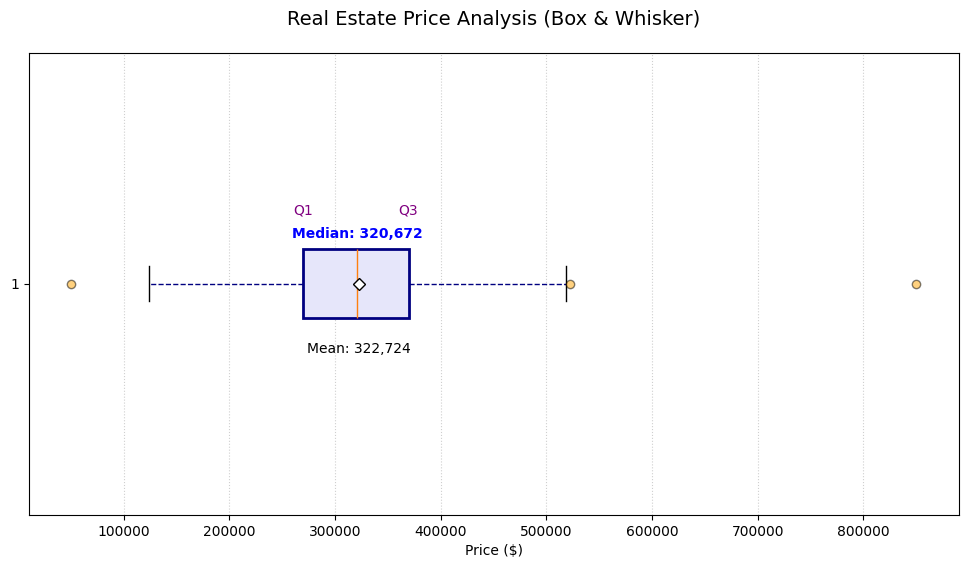

In [3]:
import matplotlib.pyplot as plt

# Calculate stats from the existing df
stats = df['Price'].describe()
q1, median, q3 = stats['25%'], stats['50%'], stats['75%']
mean = stats['mean']
iqr = q3 - q1
u_whisker = q3 + 1.5 * iqr
l_whisker = q1 - 1.5 * iqr

plt.figure(figsize=(12, 6))

# Create boxplot
bp = plt.boxplot(df['Price'], vert=False, patch_artist=True, showmeans=True,
                 meanprops={"marker":"D","markerfacecolor":"white", "markeredgecolor":"black"})

# FIX: Changed 'edgecolors' to 'edgecolor'
plt.setp(bp['boxes'], facecolor='lavender', edgecolor='navy', linewidth=2)
plt.setp(bp['whiskers'], color='navy', linestyle='--')
plt.setp(bp['fliers'], marker='o', markerfacecolor='orange', alpha=0.5)

# Annotations
plt.text(median, 1.1, f'Median: {median:,.0f}', color='blue', fontweight='bold', ha='center')
plt.text(mean, 0.85, f'Mean: {mean:,.0f}', color='black', ha='center')
plt.text(q1, 1.15, f'Q1', color='purple', ha='center')
plt.text(q3, 1.15, f'Q3', color='purple', ha='center')

plt.title('Real Estate Price Analysis (Box & Whisker)', fontsize=14, pad=20)
plt.xlabel('Price ($)')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()

In [4]:
# Calculate Measures
mean_val = df['Price'].mean()
median_val = df['Price'].median()
mode_val = df['Price'].mode()[0]  # Mode can be multiple, we take the first
std_dev = df['Price'].std()
min_val = df['Price'].min()
max_val = df['Price'].max()

# Quartiles and IQR
q1 = df['Price'].quantile(0.25)
q3 = df['Price'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identify Outliers
outliers_list = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]['Price'].values

print(f"{' MEASURE ':=^40}")
print(f"Mean (Average):      ${mean_val:,.2f}")
print(f"Median (50th %):     ${median_val:,.2f}")
print(f"Mode (Most Freq):    ${mode_val:,.2f}")
print(f"{' DISPERSION ':=^40}")
print(f"Std Deviation:       ${std_dev:,.2f}")
print(f"Interquartile Range: ${iqr:,.2f}")
print(f"Range (Min to Max):  ${min_val:,.2f} - ${max_val:,.2f}")
print(f"{' QUARTILES ':=^40}")
print(f"Q1 (25th %):         ${q1:,.2f}")
print(f"Q3 (75th %):         ${q3:,.2f}")
print(f"{' OUTLIER ANALYSIS ':=^40}")
print(f"Lower Bound:         ${lower_bound:,.2f}")
print(f"Upper Bound:         ${upper_bound:,.2f}")
print(f"Count of Outliers:   {len(outliers_list)}")
if len(outliers_list) > 0:
    print(f"Outlier Values:      {np.round(outliers_list, 2)}")

=============== MEASURE ================
Mean (Average):      $322,723.50
Median (50th %):     $320,672.10
Mode (Most Freq):    $50,000.00
============== DISPERSION ==============
Std Deviation:       $85,254.05
Interquartile Range: $99,963.64
Range (Min to Max):  $50,000.00 - $850,000.00
============== QUARTILES ===============
Q1 (25th %):         $269,569.79
Q3 (75th %):         $369,533.43
=========== OUTLIER ANALYSIS ===========
Lower Bound:         $119,624.32
Upper Bound:         $519,478.90
Count of Outliers:   3
Outlier Values:      [850000.    50000.   522686.99]


## Lasso Regression and Surface Generation

In [5]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data
X = df[['Sq_Ft', 'Age']]
y = df['Price']

# Standardizing features is crucial for Lasso
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Train Lasso Model (alpha is the penalty strength)
lasso = Lasso(alpha=100) 
lasso.fit(X_scaled, y)

# 3. Create a Meshgrid for the Hyperplane
# We create a grid over the actual range of our data
x_range = np.linspace(0, df['Sq_Ft'].max() * 1.1, 20)
y_range = np.linspace(0, df['Age'].max() * 1.1, 20)
x_mesh, y_mesh = np.meshgrid(x_range, y_range)

# Flatten grid to predict, then reshape back
# 1. Create the grid as before
grid = np.c_[x_mesh.ravel(), y_mesh.ravel()]

# 2. Convert grid to DataFrame with matching feature names to satisfy the scaler
grid_df = pd.DataFrame(grid, columns=['Sq_Ft', 'Age'])

# 3. Scale and Predict
grid_scaled = scaler.transform(grid_df)
z_predict = lasso.predict(grid_scaled).reshape(x_mesh.shape)

print(f"Lasso Coefficients: {lasso.coef_}")
print(f"Intercept: {lasso.intercept_:.2f}")

Lasso Coefficients: [ 71340.93050611 -17455.22648961]
Intercept: 322723.50


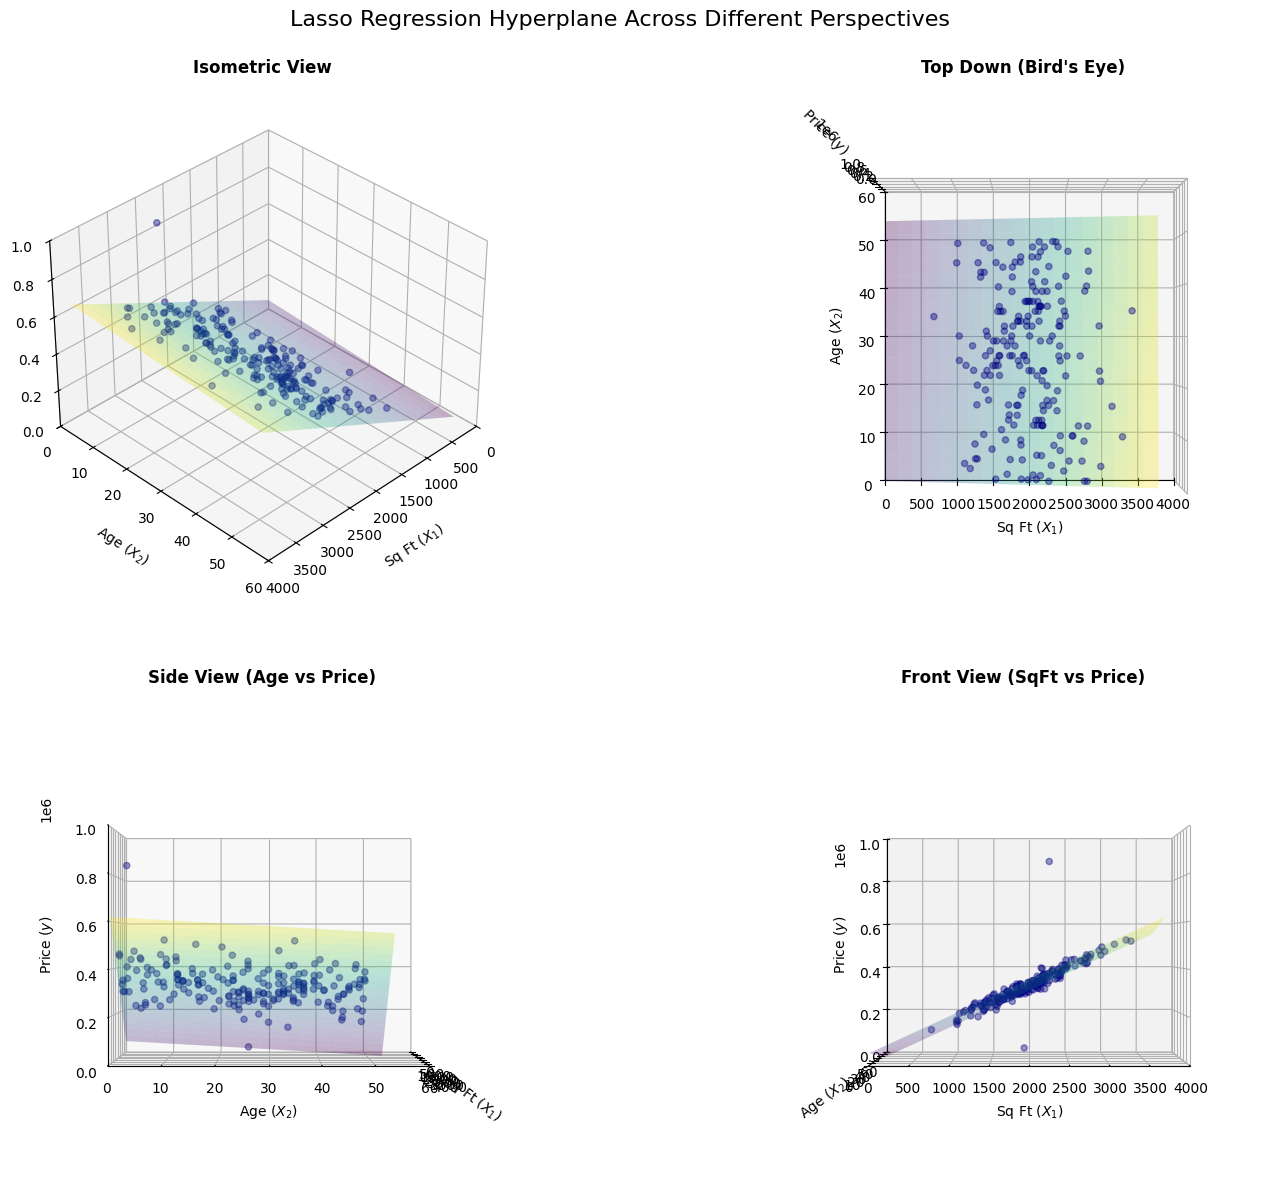

In [6]:
views = [
    {'title': 'Isometric View', 'elev': 35, 'azim': 45},
    {'title': 'Top Down (Bird\'s Eye)', 'elev': 90, 'azim': -90},
    {'title': 'Side View (Age vs Price)', 'elev': 0, 'azim': 0},
    {'title': 'Front View (SqFt vs Price)', 'elev': 0, 'azim': -90}
]

fig = plt.figure(figsize=(18, 14))

for i, v in enumerate(views, 1):
    ax = fig.add_subplot(2, 2, i, projection='3d')
    
    # Plot Data Points
    ax.scatter(df['Sq_Ft'], df['Age'], df['Price'], c='navy', alpha=0.4, s=20, label='Actual Data')
    
    # Plot Lasso Hyperplane
    # alpha=0.3 makes the plane transparent so we can see points behind it
    surf = ax.plot_surface(x_mesh, y_mesh, z_predict, cmap='viridis', alpha=0.3, antialiased=True)
    
    # Fix Origin and Limits
    ax.set_xlim(0, 4000)
    ax.set_ylim(0, 60)
    ax.set_zlim(0, 1000000)
    
    # Labels and Titles
    ax.set_xlabel('Sq Ft ($X_1$)', labelpad=10)
    ax.set_ylabel('Age ($X_2$)', labelpad=10)
    ax.set_zlabel('Price ($y$)', labelpad=10)
    ax.set_title(v['title'], pad=25, fontsize=12, fontweight='bold')
    
    ax.view_init(elev=v['elev'], azim=v['azim'])

plt.subplots_adjust(wspace=0.2, hspace=0.3)
plt.suptitle('Lasso Regression Hyperplane Across Different Perspectives', fontsize=16, y=0.95)
plt.show()

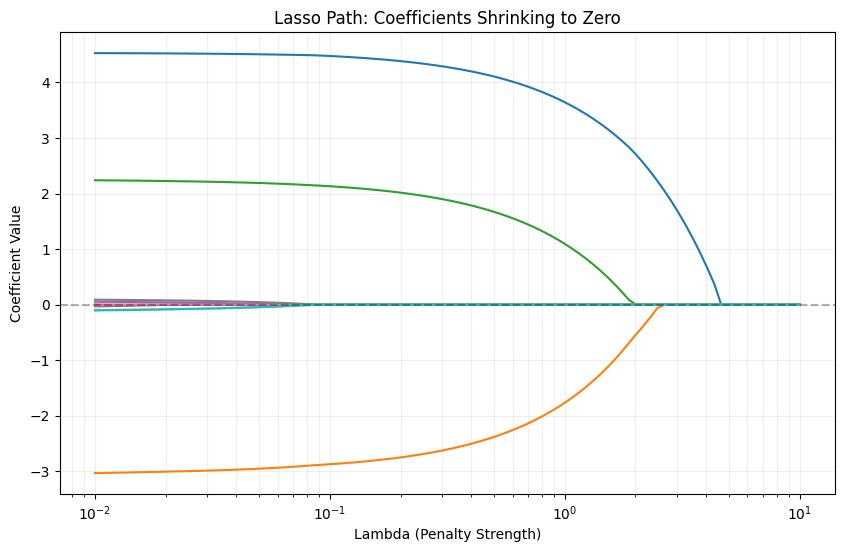

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# 1. Create a dataset with 10 features, but only 3 are actually relevant
np.random.seed(42)
n_samples, n_features = 50, 10
X = np.random.randn(n_samples, n_features)
# Only features 0, 1, and 2 have non-zero coefficients
true_coefs = [5, -3, 2] + [0] * (n_features - 3)
y = X @ true_coefs + np.random.normal(0, 0.5, n_samples)

# 2. Standardize features (Crucial for Lasso!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit Lasso with different Lambda (alpha) values
alphas = np.logspace(-2, 1, 100)
coefs = []

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

# 4. Plot the "Path" of coefficients
plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale('log')
plt.xlabel('Lambda (Penalty Strength)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Path: Coefficients Shrinking to Zero')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

To see every step of the Lasso Regression process, we need to bridge the gap between the high-level objective function and the actual algorithmic updates. Lasso is unique because the $L_1$ penalty ($|\beta|$) is not differentiable at zero, so we cannot use the standard "Set gradient to zero" approach. Instead, we use **Coordinate Descent**.

Here is the step-by-step breakdown from the data to the final zero-coefficient.

---

## 1. The Setup: Data and Objective
We start with a dataset of $m$ observations and $n$ features. 

**The Objective Function:**
$$J(\beta) = \frac{1}{2m} \sum_{i=1}^{m} (y_i - \sum_{j=1}^{n} X_{ij}\beta_j)^2 + \lambda \sum_{j=1}^{n} |\beta_j|$$

* **Part A (MSE):** Tries to minimize the distance to data points.
* **Part B (L1 Penalty):** Tries to minimize the absolute sum of weights.

---

## 2. Step-by-Step Mathematical Optimization
Since we can't use a simple derivative, we update one coefficient $\beta_j$ at a time.

### Step 2.1: Isolate the Feature
For a specific coefficient $\beta_j$, we treat all other coefficients ($\beta_{k \neq j}$) as fixed constants. We define the **Partial Residual** ($r_i^{(j)}$) as the error remaining if we ignore feature $j$:
$$r_i^{(j)} = y_i - \sum_{k \neq j} X_{ik}\beta_k$$

### Step 2.2: Compute the Correlation ($\rho_j$)
We calculate how much feature $j$ "explains" the remaining error:
$$\rho_j = \sum_{i=1}^{m} X_{ij} r_i^{(j)}$$

### Step 2.3: The Soft-Thresholding Rule
This is the "magic" of Lasso. We apply the threshold $\lambda$:
$$\hat{\beta}_j = 
\begin{cases} 
\frac{\rho_j + \lambda}{z_j} & \text{if } \rho_j < -\lambda \\
0 & \text{if } -\lambda \leq \rho_j \leq \lambda \\
\frac{\rho_j - \lambda}{z_j} & \text{if } \rho_j > \lambda 
\end{cases}$$
*(Where $z_j = \sum X_{ij}^2$, often 1 if data is normalized).*

In [8]:
import numpy as np
import pandas as pd

# 1. INITIAL DATASET
# 1. GENERATE RANDOM DATA (10 samples, 2 features)
np.random.seed(42)
n_samples = 10

# Generate and round to integers
X_raw = np.round(np.random.rand(n_samples, 2) * 10).astype(int)
# Target y: High dependence on x1, very low/noise dependence on x2
# y = 2*x1 + 0.1*x2 + noise
y_raw = 2 * X_raw[:, 0] + 0.1 * X_raw[:, 1] + np.random.normal(0, 1, n_samples)

df_initial = pd.DataFrame(X_raw, columns=["x1", "x2"])
df_initial["y"] = y_raw
print("--- Initial Dataset ---")
print(df_initial)
print("\n" + "=" * 50 + "\n")

# 2. PREPROCESSING (Standardization)
# Lasso is scale-dependent, so we must center y and scale X
y = y_raw - np.mean(y_raw)
X = (X_raw - np.mean(X_raw, axis=0)) / np.std(X_raw, axis=0)

print("--- Preprocessed Data (Centered y, Scaled X) ---")
df_proc = pd.DataFrame(X, columns=["x1_scaled", "x2_scaled"])
df_proc["y_centered"] = y
print(df_proc)
print("\n" + "=" * 50 + "\n")

# 3. SETTINGS
lmbda = 10.0  # The penalty strength
beta = np.zeros(X.shape[1])  # Start weights at [0, 0]
epsilon = 1e-6  # Convergence threshold
max_passes = 100  # Safety break


def soft_threshold(rho, lmbda):
    """The 'Gatekeeper' function of Lasso"""
    if rho < -lmbda:
        return rho + lmbda
    elif rho > lmbda:
        return rho - lmbda
    else:
        return 0.0


# --- COORDINATE DESCENT WITH CONVERGENCE ---
for pass_num in range(1, max_passes + 1):
    beta_old = beta.copy()

    # 4. STEP-BY-STEP COORDINATE DESCENT (One Pass)
    for j in range(len(beta)):
        print(f"--- STEP: Updating Feature x{j+1} ---")

        # Calculate Prediction using all OTHER features
        # y_pred = X_1*beta_1 + X_2*beta_2 ...
        y_pred_others = np.dot(X, beta) - (X[:, j] * beta[j])

        # Calculate Partial Residual (The error left to explain)
        r_j = y - y_pred_others
        print(f"  Current Predictions (others): {y_pred_others}")
        print(f"  Partial Residuals (r_j):     {r_j}")

        # Calculate Correlation (rho)
        # How much does feature x_j match the remaining error?
        rho_j = np.dot(X[:, j], r_j)
        print(f"  Correlation (rho_j):         {rho_j:.4f}")

        # Apply the Penalty
        # We divide by the sum of squares of the feature (normalization factor)
        z_j = np.sum(X[:, j] ** 2)
        old_beta = beta[j]
        beta[j] = soft_threshold(rho_j, lmbda) / z_j

        print(f"  Penalty (lambda):             {lmbda}")
        print(f"  Soft Thresholding Result:     {soft_threshold(rho_j, lmbda):.4f}")
        print(f"  Final Weight Beta_{j+1}:      {beta[j]:.4f}")

        if beta[j] == 0 and rho_j != 0:
            print(f"  RESULT: Feature x{j+1} eliminated (rho < lambda)")
        else:
            print(f"  RESULT: Feature x{j+1} kept (rho > lambda)")
        print("\n")

    print(f"Pass {pass_num}, Beta = {beta}")
    print("=" * 50)
    print("\n")

    # Check if the change is smaller than our threshold
    diff = np.max(np.abs(beta - beta_old))
    print(f"Pass {pass_num}: Max Change in Beta = {diff:.8f}")

    if diff < epsilon:
        print(f"CONVERGED at Pass {pass_num}")
        break

print(f"\nFinal Stable Betas: {beta}")

--- Initial Dataset ---
   x1  x2          y
0   4  10   7.987169
1   7   6  14.914247
2   2   2   3.291976
3   1   9   1.487696
4   6   7  14.165649
5   0  10   0.774224
6   8   2  16.267528
7   2   2   2.775252
8   3   5   5.955617
9   4   3   8.410923


--- Preprocessed Data (Centered y, Scaled X) ---
   x1_scaled  x2_scaled  y_centered
0   0.120386   1.402669    0.384141
1   1.324244   0.127515    7.311219
2  -0.682187  -1.147638   -4.311052
3  -1.083473   1.083880   -6.115332
4   0.922958   0.446304    6.562621
5  -1.484759   1.402669   -6.828804
6   1.725531  -1.147638    8.664500
7  -0.682187  -1.147638   -4.827776
8  -0.280900  -0.191273   -1.647411
9   0.120386  -0.828850    0.807895


--- STEP: Updating Feature x1 ---
  Current Predictions (others): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Partial Residuals (r_j):     [ 0.3841408   7.31121925 -4.31105215 -6.11533178  6.56262069 -6.82880438
  8.66450013 -4.82777626 -1.6474108   0.80789451]
  Correlation (rho_j):         54.2953
  Pen

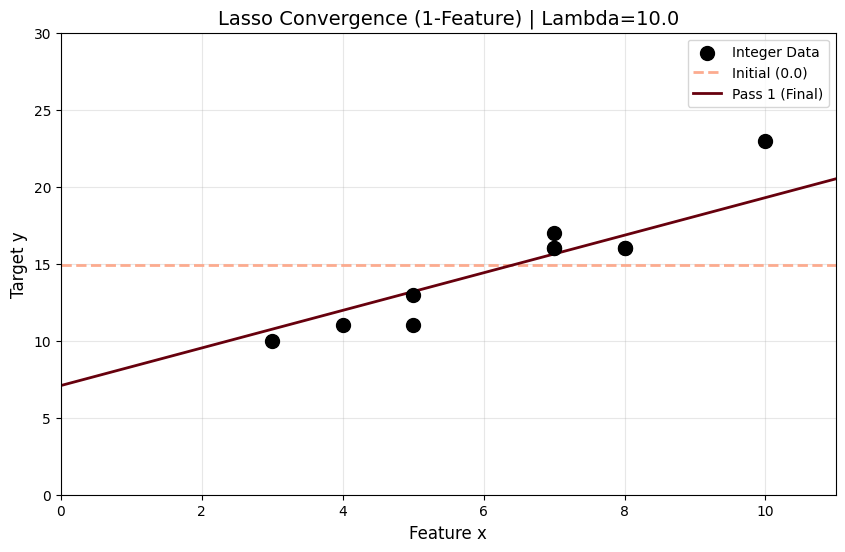

Final Weight (Beta): 2.4528


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. GENERATE SIMPLE INTEGER DATA (10x1)
np.random.seed(42)
X_raw = np.sort(np.random.randint(1, 11, size=(10, 1)), axis=0)
# y is roughly 2.5 * x
y_raw = (2.5 * X_raw.flatten() + np.random.normal(0, 2, 10)).astype(int)

# 2. PREPROCESSING
y_mean = np.mean(y_raw)
y_centered = y_raw - y_mean
X_mean = np.mean(X_raw)
X_std = np.std(X_raw)
X_scaled = (X_raw - X_mean) / X_std

# 3. RUN LASSO (Updating until convergence)
lmbda = 10.0  # Penalty
beta = 0.0
history = [beta]
epsilon = 1e-6

def soft_threshold(rho, lmbda):
    if rho < -lmbda: return rho + lmbda
    elif rho > lmbda: return rho - lmbda
    else: return 0.0

# In a 1-feature model, convergence is usually instant
for i in range(5):
    rho = np.dot(X_scaled.flatten(), y_centered)
    z = np.sum(X_scaled**2)
    new_beta = soft_threshold(rho, lmbda) / z
    
    if abs(new_beta - beta) < epsilon:
        break
    beta = new_beta
    history.append(beta)

# 4. 2D VISUALIZATION
plt.figure(figsize=(10, 6))
plt.scatter(X_raw, y_raw, color='black', s=100, label='Integer Data', zorder=5)

# Plot the lines for each pass
x_plot = np.linspace(0, 11, 100)
x_plot_scaled = (x_plot - X_mean) / X_std

colors = plt.cm.Reds(np.linspace(0.3, 1, len(history)))

for i, b in enumerate(history):
    y_plot = (b * x_plot_scaled) + y_mean
    label = "Initial (0.0)" if i == 0 else f"Pass {i} (Final)"
    plt.plot(x_plot, y_plot, color=colors[i], lw=2, label=label, 
             linestyle='--' if i == 0 else '-')

plt.title(f"Lasso Convergence (1-Feature) | Lambda={lmbda}", fontsize=14)
plt.xlabel("Feature x", fontsize=12)
plt.ylabel("Target y", fontsize=12)
plt.xlim(0, 11)
plt.ylim(0, 30)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Final Weight (Beta): {beta:.4f}")